In [140]:
pip install biopython requests matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [183]:
import requests as requests
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
from matplotlib.colors import from_levels_and_colors
from matplotlib.collections import LineCollection

from Bio.PDB import *

In [142]:
def getbfactor(url, name):
    name = name.replace(" ", "_")
    name = requests.get(str(url))
    
    url_name = str(name)+".pdb"
    
    with open(url_name, "w") as f:    
        f.write(name.text)

    structure = PDBParser().get_structure(str(name), url_name)

    bfactor = []
    
    for residue in structure.get_residues():
        if "CA" in residue:
            bfactor.append(residue["CA"].get_bfactor())
    return bfactor

RTCB = getbfactor("https://alphafold.ebi.ac.uk/files/AF-Q9Y3I0-F1-model_v6.pdb", "RTCB")

In [ ]:
def highlow(protein):
    return "The lowest pLDDT value is " + str(min(protein)) + " and the highest is " + str(max(protein))
highlow(RTCB)

In [182]:
def percents(protein): 
    '''Takes in a protein's bfactor list
    Returns the percentages of iPLDDT for the protein'''
    mean_pLDDT = np.average(protein)

    high = 0
    avg = 0
    mid = 0
    low = 0

    for i in protein:
        if i > 90:
            high += 1
        elif 70 < i <= 90:
            avg += 1
        elif 50 < i <= 70:
            mid += 1
        elif i < 50:
            low += 1

    length = len(protein)/100
   # round = lambda a : a.round(2)
    numbers = [high/length, avg/length, mid/length, low/length]
    return pd.DataFrame(data = list(map(lambda x: round(x,2), numbers)), index = ['>90','70-90','50-70','<50'])
#list(map(lambda x: x * 2, numbers))
percents(RTCB)

,0
>90,88.32
70-90,10.50
50-70,1.19
<50,0.00


In [153]:
def disorder(protein):
    '''Input the bfactor file of a protein
    The function will return the longest stretch of suspected disordered residues and its range'''
    start_longest = None
    end_longest = None
    longest = 0
    num_residues = 0

    for index, value in enumerate(protein): 
        if value < 50:
            num_residues += 1
        
            if num_residues > longest:
                longest = num_residues
                end_longest = index + 1
                start_longest = end_longest - longest

        else:
            num_residues = 0
    
    if start_longest == None:
        return "This protein does not have disorder"
    else:
        return "This protein is " + str(percents(protein).iloc[3,0]) + "% disordered. The longest chain of disorder is " + str(longest) + " residues from " + str(start_longest) + " - " + str(end_longest) + "."
        
disorder(RTCB)

'This protein does not have disorder'

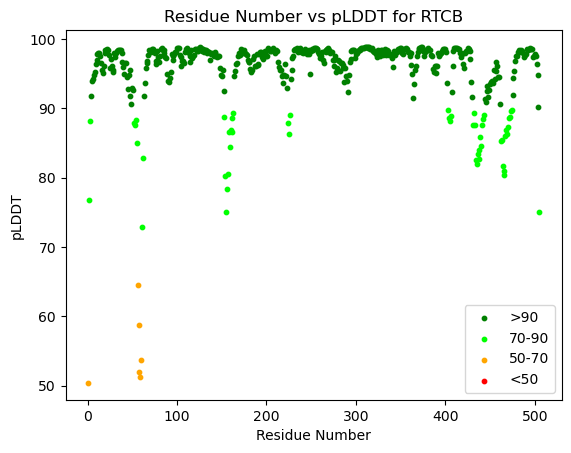

In [179]:
def scatterbycolor(x, y, protein_name):
    '''Takes in array for x value, array for y value
    Returns a plot that scatters by color'''
    
    x = np.array(x)
    y = np.array(y)

    plt.scatter(x[y > 90], y[y > 90], color='green', s=10, label='>90')
    plt.scatter(x[(y > 70) & (y <= 90)], y[(y > 70) & (y <= 90)], color='lime', s=10, label='70-90')
    plt.scatter(x[(y > 50) & (y <= 70)], y[(y > 50) & (y <= 70)], color='orange', s=10, label='50-70')
    plt.scatter(x[y <= 50], y[y <= 50], color='red', s=10, label='<50')

    plt.title("Residue Number vs pLDDT for " + str(protein_name))
    plt.xlabel("Residue Number")
    plt.ylabel("pLDDT")
    plt.legend()
    return plt.show()
    
residueindex = np.arange(1,len(RTCB) + 1)
scatterbycolor(residueindex, RTCB, "RTCB")

Let's compare the pLDDT value (AI's confidence that their prediction matches the reality) for a solved intrinsically disordered protein and for a solved well-folded protein.

In [ ]:
url1 = "https://alphafold.ebi.ac.uk/files/AF-P46527-F1-model_v6.pdb"
CDK2 = getbfactor(url1, "p27 cyclin CDK2")
url2 = "https://alphafold.ebi.ac.uk/files/AF-P22121-F1-model_v6.pdb"
heat_shock = getbfactor(url2, "heat shock factor protein")
url3 = "https://alphafold.ebi.ac.uk/files/AF-Q9Y3I0-F1-model_v6.pdb"
print(disorder(CDK2))
print(disorder(heat_shock))
disorder(getbfactor(url3, "RTCB"))

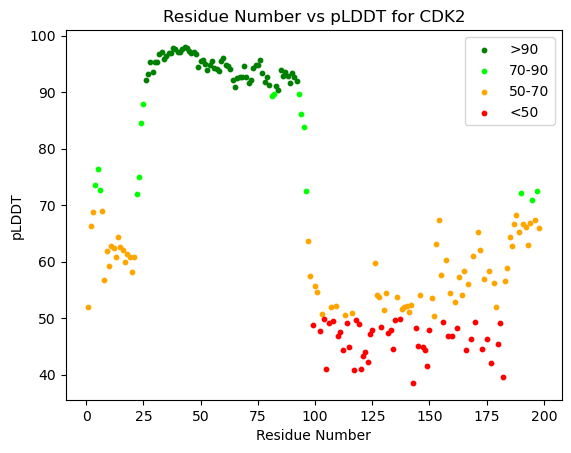

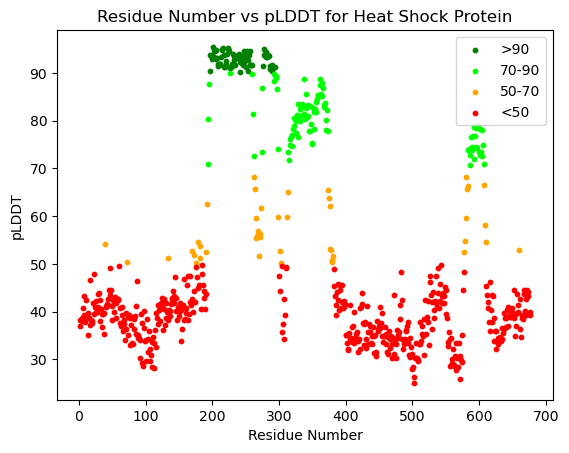

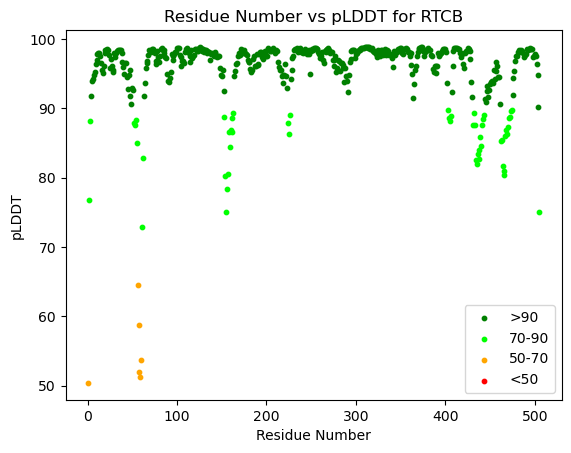

In [180]:
index1 = np.arange(1,len(CDK2) + 1)
index2 = np.arange(1,len(heat_shock) + 1)
index3 = np.arange(1,len(RTCB) + 1)
scatterbycolor(index1, CDK2, "CDK2")
scatterbycolor(index2, heat_shock, "Heat Shock Protein")
scatterbycolor(index3, RTCB, "RTCB")

References cited:
https://pmc.ncbi.nlm.nih.gov/articles/PMC3799472/
https://alphafold.ebi.ac.uk/#/public-api/get_predictions_api_prediction__qualifier__get
https://www.disprot.org/browse?sort_field=disprot_id&sort_value=asc&page_size=20&page=0&release=current&show_ambiguous=true&show_obsolete=false&free_text=P22121
maybe do something with this: https://www.nature.com/articles/s41467-025-66420-5
https://rcsb.org/3d-view/1JSU
https://www.nature.com/articles/382325a0 